# CARGAR DATOS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# Semilla para reproducibilidad
random_state = 42
np.random.seed(random_state)

In [ ]:
from google.colab import drive
#if not os.path.exists('output_data_enriched.csv'):
 # uploaded = files.upload()

#  for fn in uploaded.keys():
 #   print('User uploaded file "{name}" with length {length} bytes'.format(
  #      name=fn, length=len(uploaded[fn])))

drive.mount('/content/drive')

data = pd.read_csv("/content/drive/MyDrive/output_data_enriched.csv", on_bad_lines='skip', sep='|')

#data = pd.read_csv('output_data_enriched.csv', on_bad_lines='skip', sep='|')

print(f'Tamaño del dataset: {data.shape}')

data.head()

Mounted at /content/drive
Tamaño del dataset: (12721, 74)


,direccion,precio_uf,metros_cuadrados,dormitorios,banios,latitude,longitude,centros_comerciales_tiempo(minutos)_min,centros_comerciales_tiempo(minutos)_max,centros_comerciales_tiempo(minutos)_avg,...,supermercados_dist(metros)_min,supermercados_dist(metros)_max,supermercados_dist(metros)_avg,universidades_tiempo(minutos)_min,universidades_tiempo(minutos)_max,universidades_tiempo(minutos)_avg,universidades_dist(metros)_min,universidades_dist(metros)_max,universidades_dist(metros)_avg,url
0,"Zenteno / Pedro Lagos / San Diego, Parque O'Hi...",1690,38,2,1,-33.465703,-70.649803,NaN,NaN,NaN,...,242.9,242.9,242.9,NaN,NaN,NaN,NaN,NaN,NaN,https://www.portalinmobiliario.com/MLC-1440730...
1,"Metro Moneda, Bulnes, Santiago, RM (Metropolit...",2025,28,1,1,-33.446480,-70.653803,7.9,10.6,9.6,...,110.1,980.7,557.0,0.6,11.9,8.3,48.1,990.5,691.4,https://www.portalinmobiliario.com/MLC-1478418...
2,"Av. España 683, Santiago, Chile, Barrio Repúbl...",4603,84,3,2,-33.456851,-70.668776,NaN,NaN,NaN,...,700.2,820.6,760.4,1.5,12.0,9.2,124.5,999.3,769.6,https://www.portalinmobiliario.com/MLC-1441884...
3,"Parque De Los Reyes, Parque Los Reyes, Santiag...",2570,42,1,1,-33.430355,-70.666431,NaN,NaN,NaN,...,NaN,NaN,NaN,11.9,11.9,11.9,994.9,994.9,994.9,https://www.portalinmobiliario.com/MLC-1443714...
4,"Arturo Prat//victoria//metro Avenida Matta, Pa...",1752,40,2,1,-33.464671,-70.646844,NaN,NaN,NaN,...,357.1,357.1,357.1,NaN,NaN,NaN,NaN,NaN,NaN,https://www.portalinmobiliario.com/MLC-1478137...


In [ ]:
data.columns

Index(['direccion', 'precio_uf', 'metros_cuadrados', 'dormitorios', 'banios',
       'latitude', 'longitude', 'centros_comerciales_tiempo(minutos)_min',
       'centros_comerciales_tiempo(minutos)_max',
       'centros_comerciales_tiempo(minutos)_avg',
       'centros_comerciales_dist(metros)_min',
       'centros_comerciales_dist(metros)_max',
       'centros_comerciales_dist(metros)_avg', 'clinicas_tiempo(minutos)_min',
       'clinicas_tiempo(minutos)_max', 'clinicas_tiempo(minutos)_avg',
       'clinicas_dist(metros)_min', 'clinicas_dist(metros)_max',
       'clinicas_dist(metros)_avg', 'colegios_tiempo(minutos)_min',
       'colegios_tiempo(minutos)_max', 'colegios_tiempo(minutos)_avg',
       'colegios_dist(metros)_min', 'colegios_dist(metros)_max',
       'colegios_dist(metros)_avg', 'estaciones_de_metro_tiempo(minutos)_min',
       'estaciones_de_metro_tiempo(minutos)_max',
       'estaciones_de_metro_tiempo(minutos)_avg',
       'estaciones_de_metro_dist(metros)_min',
       '

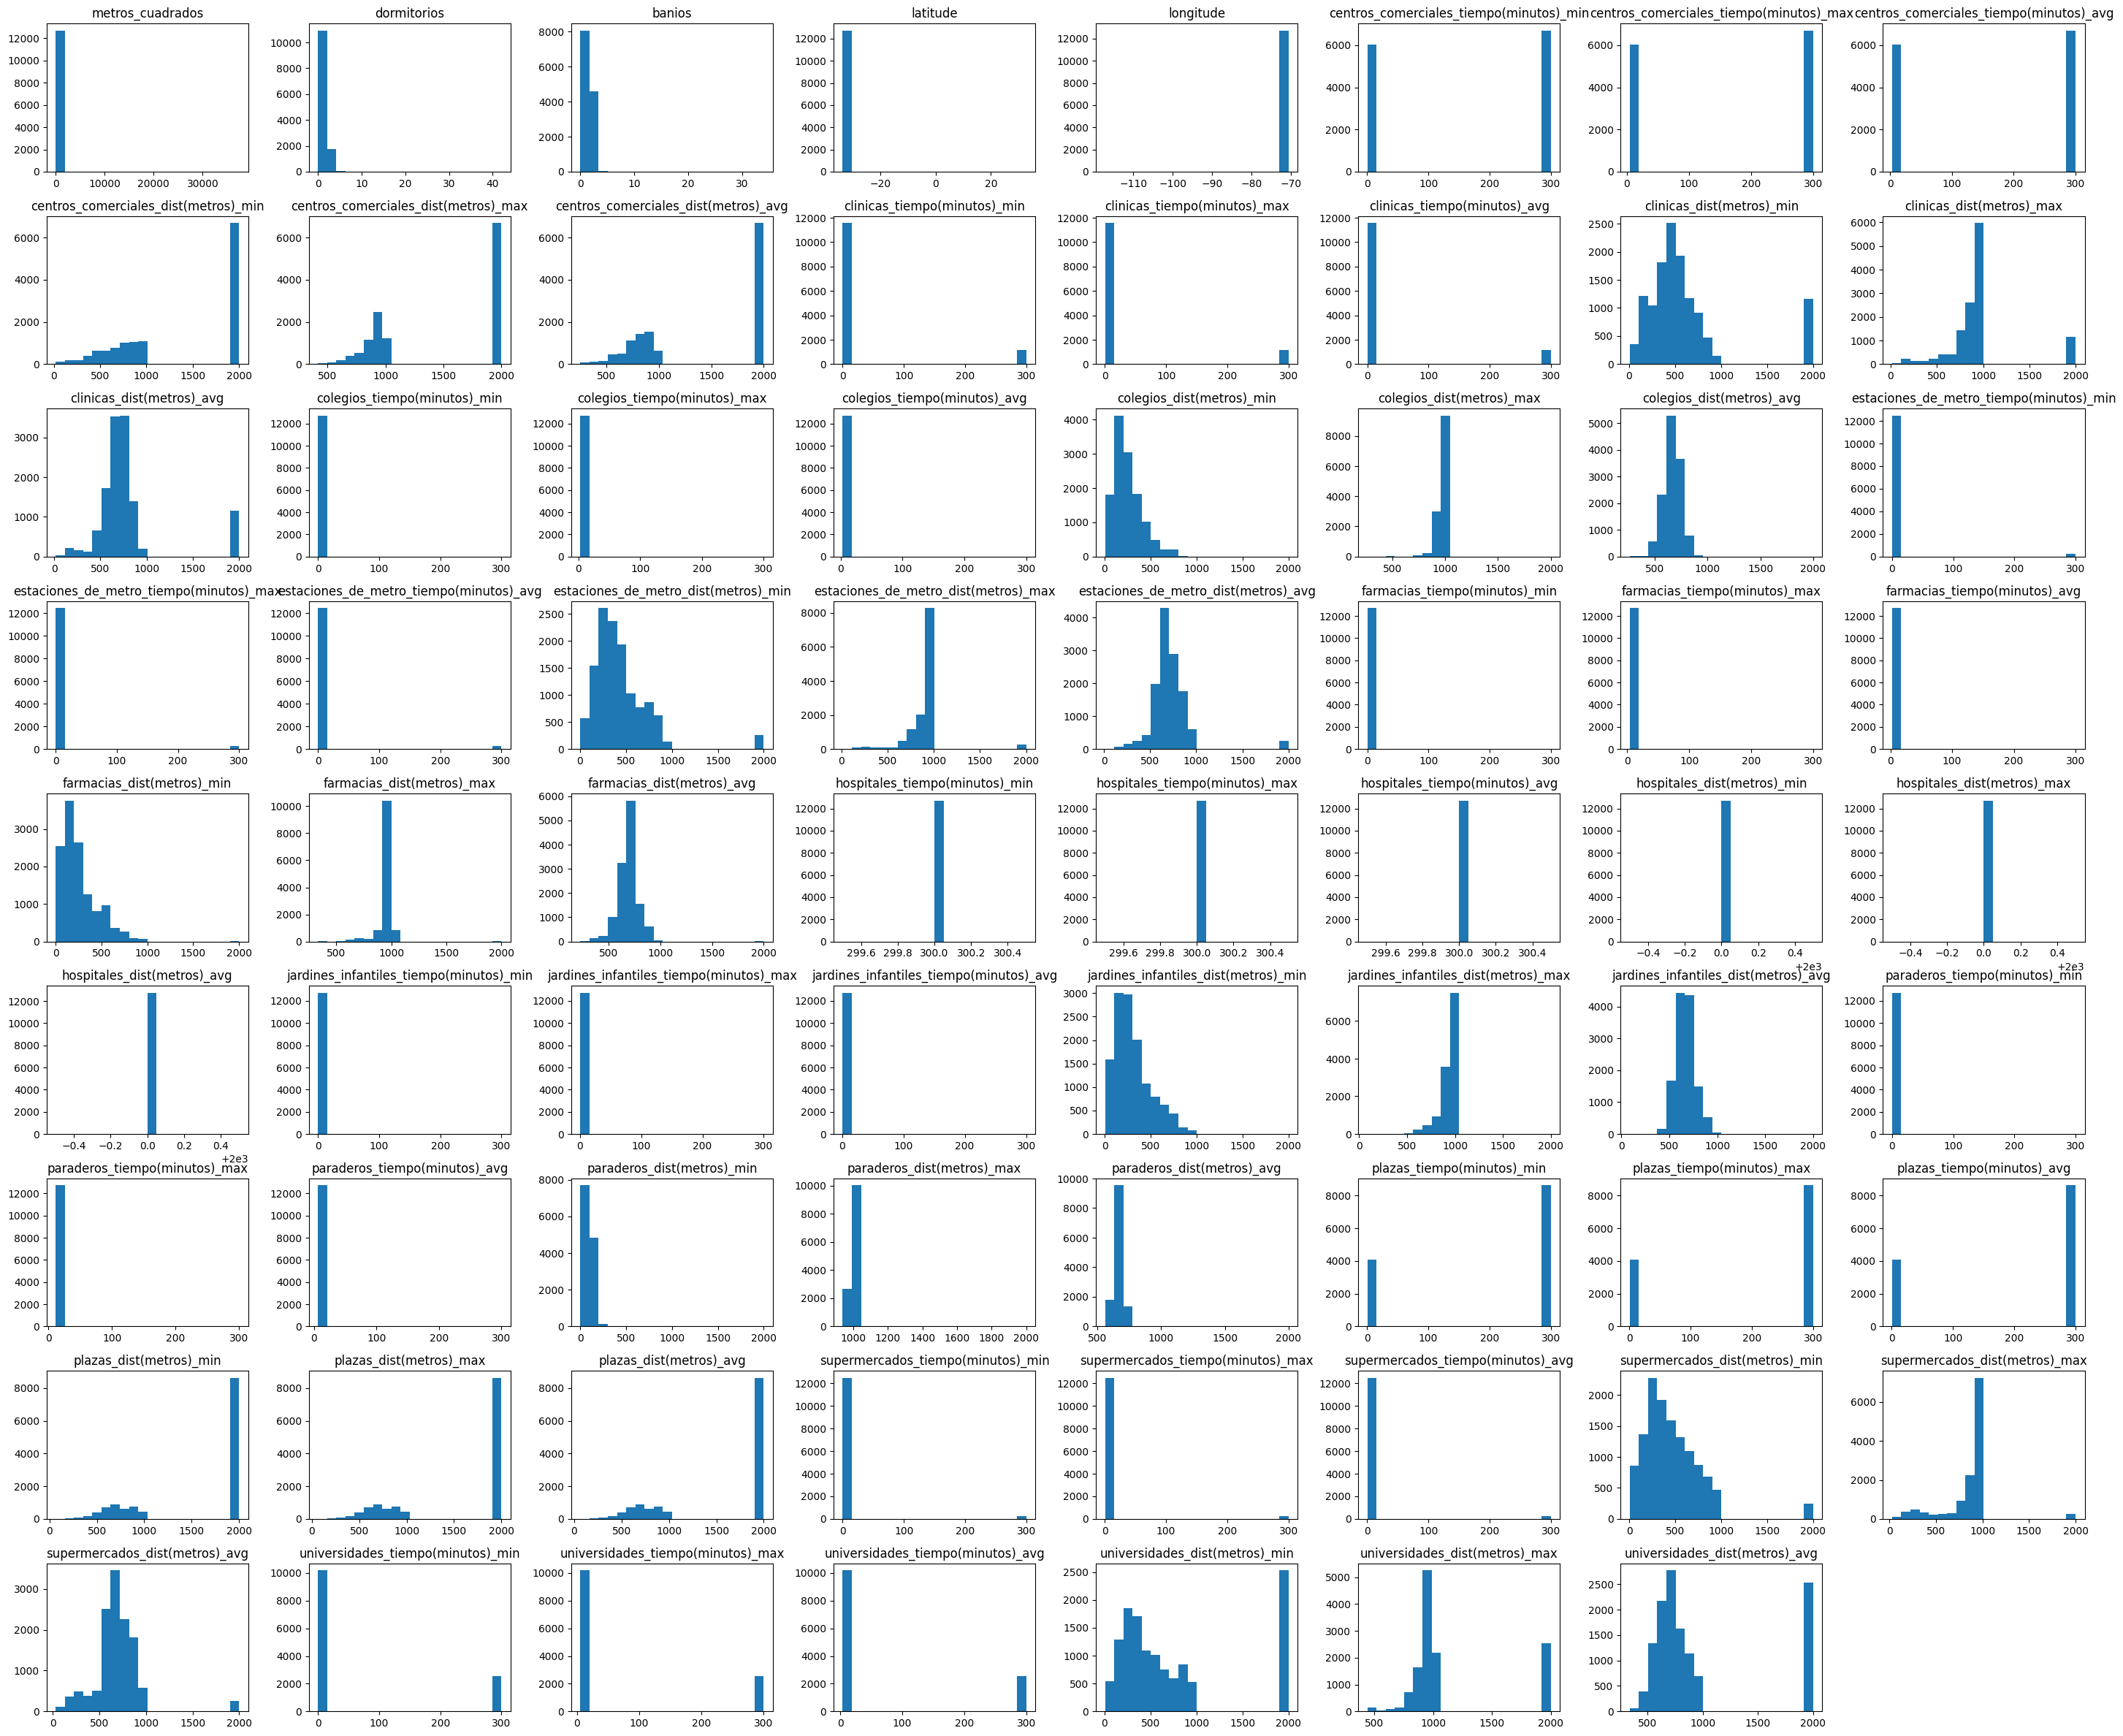

In [ ]:
# Histogramas de las características
data.drop('precio_uf', axis=1).hist(figsize=(36,30),bins=20, grid=False)
plt.title('Histogramas de las características')
plt.show()

# LLENAR DATOS VACIOS

In [ ]:
# Revisar si existen valores nulos

print(f'Cantidad de valores nulos: {data.isnull().sum().sum()}')

Cantidad de valores nulos: 193398


In [ ]:
# Reemplazar valores vacios

m = data.columns[data.columns.str.contains('minutos')]
data.loc[:, m] = data.loc[:, m].fillna(60) # Reemplazo vacios por 60 minutos

m = data.columns[data.columns.str.contains('metros')]
data.loc[:, m] = data.loc[:, m].fillna(2000) # Reemplazo vacios por 2000 metros

In [ ]:
data.head()

,direccion,precio_uf,metros_cuadrados,dormitorios,banios,latitude,longitude,centros_comerciales_tiempo(minutos)_min,centros_comerciales_tiempo(minutos)_max,centros_comerciales_tiempo(minutos)_avg,...,supermercados_dist(metros)_min,supermercados_dist(metros)_max,supermercados_dist(metros)_avg,universidades_tiempo(minutos)_min,universidades_tiempo(minutos)_max,universidades_tiempo(minutos)_avg,universidades_dist(metros)_min,universidades_dist(metros)_max,universidades_dist(metros)_avg,url
0,"Zenteno / Pedro Lagos / San Diego, Parque O'Hi...",1690,38,2,1,-33.465703,-70.649803,300.0,300.0,300.0,...,242.9,242.9,242.9,300.0,300.0,300.0,2000.0,2000.0,2000.0,https://www.portalinmobiliario.com/MLC-1440730...
1,"Metro Moneda, Bulnes, Santiago, RM (Metropolit...",2025,28,1,1,-33.446480,-70.653803,7.9,10.6,9.6,...,110.1,980.7,557.0,0.6,11.9,8.3,48.1,990.5,691.4,https://www.portalinmobiliario.com/MLC-1478418...
2,"Av. España 683, Santiago, Chile, Barrio Repúbl...",4603,84,3,2,-33.456851,-70.668776,300.0,300.0,300.0,...,700.2,820.6,760.4,1.5,12.0,9.2,124.5,999.3,769.6,https://www.portalinmobiliario.com/MLC-1441884...
3,"Parque De Los Reyes, Parque Los Reyes, Santiag...",2570,42,1,1,-33.430355,-70.666431,300.0,300.0,300.0,...,2000.0,2000.0,2000.0,11.9,11.9,11.9,994.9,994.9,994.9,https://www.portalinmobiliario.com/MLC-1443714...
4,"Arturo Prat//victoria//metro Avenida Matta, Pa...",1752,40,2,1,-33.464671,-70.646844,300.0,300.0,300.0,...,357.1,357.1,357.1,300.0,300.0,300.0,2000.0,2000.0,2000.0,https://www.portalinmobiliario.com/MLC-1478137...


# PRE PROCESAMIENTO DE DATOS

In [ ]:
# Separar datos en train y test
from sklearn.model_selection import train_test_split

X = data.drop(['precio_uf', 'direccion', 'hospitales_tiempo(minutos)_min',
       'hospitales_tiempo(minutos)_max', 'hospitales_tiempo(minutos)_avg',
       'hospitales_dist(metros)_min', 'hospitales_dist(metros)_max',
       'hospitales_dist(metros)_avg', 'url'], axis=1)
y = data['precio_uf']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

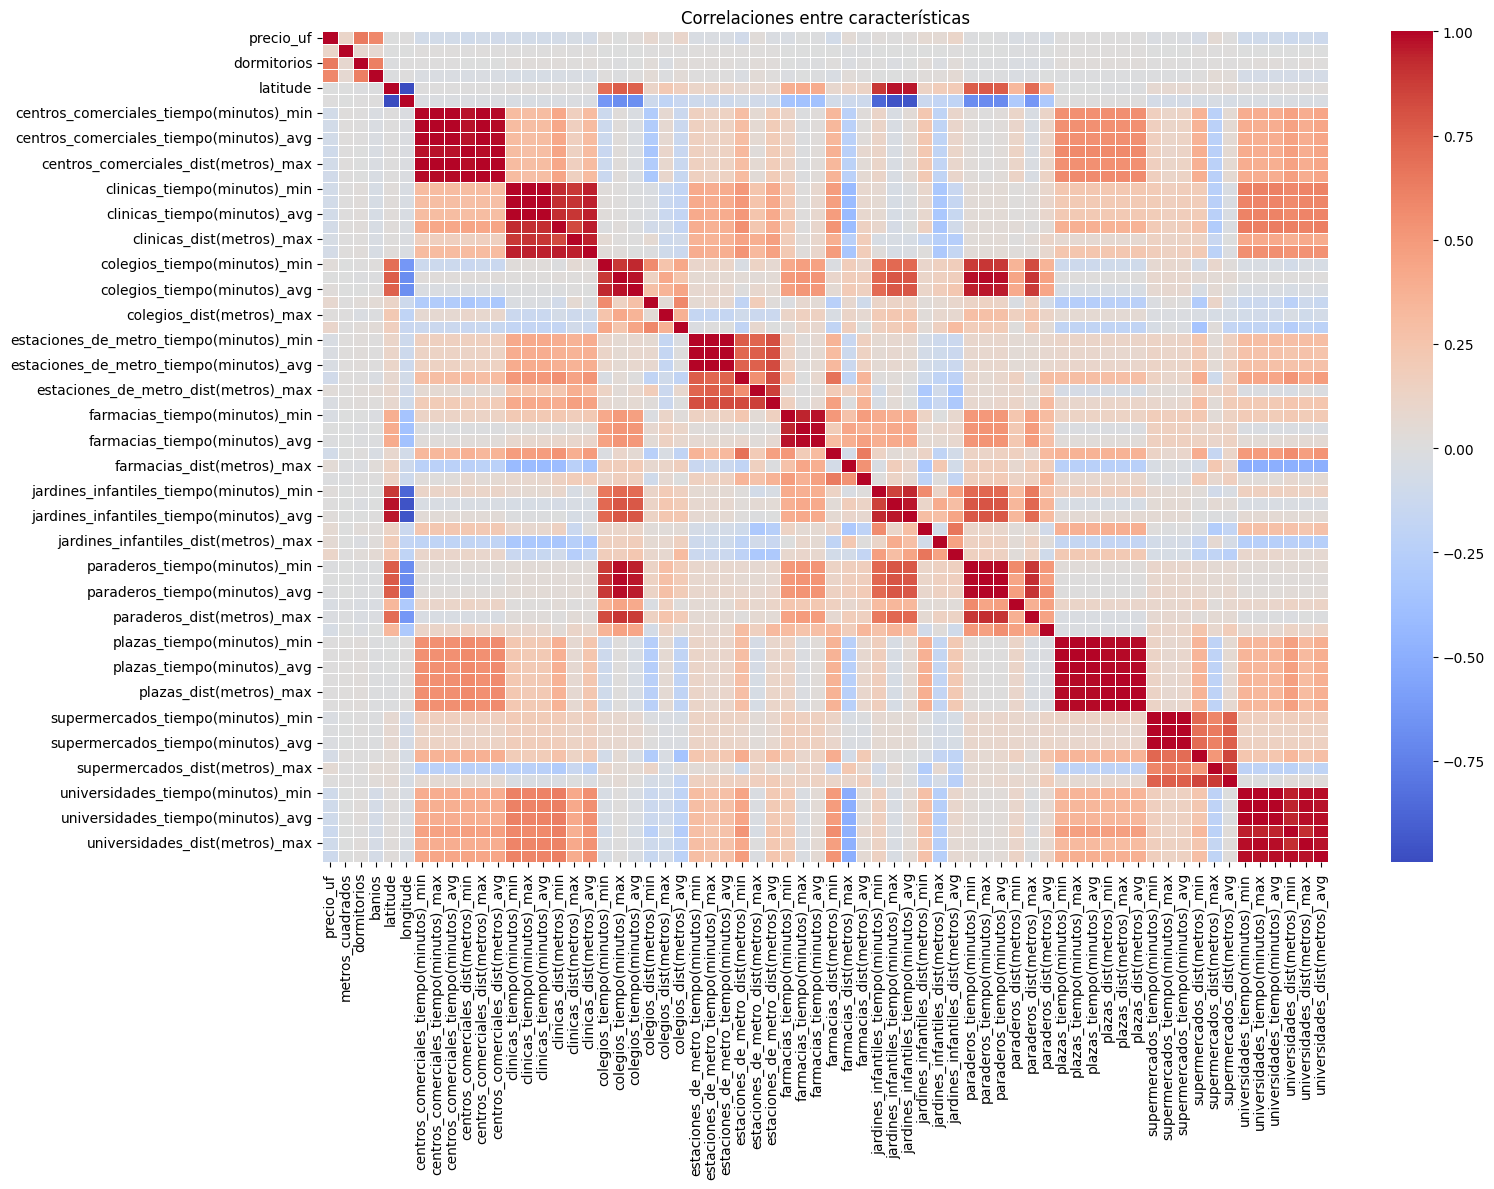

In [ ]:
# Mapa de calor de las correlaciones
datos = data.drop(['direccion', 'hospitales_tiempo(minutos)_min',
       'hospitales_tiempo(minutos)_max', 'hospitales_tiempo(minutos)_avg',
       'hospitales_dist(metros)_min', 'hospitales_dist(metros)_max',
       'hospitales_dist(metros)_avg', 'url'], axis=1)
corr_matrix = datos.corr()

plt.figure(figsize=(16,12))
plt.title('Correlaciones entre características')
sns.heatmap(corr_matrix, cmap='coolwarm', linewidth=0.5)
plt.tight_layout()
plt.show()

In [ ]:
def get_high_corr_pairs(corr_matrix):
    high_corr_pairs = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= 0.9:
                high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j]))

    return high_corr_pairs

print("\nCaracterísticas con correlación >= 0.9 entre sí:\n")
for pair in get_high_corr_pairs(corr_matrix):
    print(pair)

print("\nCaracterísticas con correlación < 0.05 con el objetivo:\n")
for i in corr_matrix['precio_uf'][abs(corr_matrix['precio_uf']) < 0.05].index:
  print(i)


Características con correlación >= 0.9 entre sí:

('latitude', 'longitude')
('latitude', 'jardines_infantiles_tiempo(minutos)_max')
('latitude', 'jardines_infantiles_tiempo(minutos)_avg')
('longitude', 'jardines_infantiles_tiempo(minutos)_max')
('longitude', 'jardines_infantiles_tiempo(minutos)_avg')
('centros_comerciales_tiempo(minutos)_min', 'centros_comerciales_tiempo(minutos)_max')
('centros_comerciales_tiempo(minutos)_min', 'centros_comerciales_tiempo(minutos)_avg')
('centros_comerciales_tiempo(minutos)_min', 'centros_comerciales_dist(metros)_min')
('centros_comerciales_tiempo(minutos)_min', 'centros_comerciales_dist(metros)_max')
('centros_comerciales_tiempo(minutos)_min', 'centros_comerciales_dist(metros)_avg')
('centros_comerciales_tiempo(minutos)_max', 'centros_comerciales_tiempo(minutos)_avg')
('centros_comerciales_tiempo(minutos)_max', 'centros_comerciales_dist(metros)_min')
('centros_comerciales_tiempo(minutos)_max', 'centros_comerciales_dist(metros)_max')
('centros_comerc

# MODELO RANDOMFOREST


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

regr = make_pipeline(StandardScaler(), RandomForestRegressor(random_state=42))
regr.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [ ]:
regr.score(X_train, y_train)

0.967767042967903

In [ ]:
y_pred = regr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error

# Define los rangos
rangos = [(0, 1000), (1000, 2000), (2000, 3000), (3000, 4000), (4000, 5000), (5000, 50000)]

for rango in rangos:
    mask = (y_test > rango[0]) & (y_test <= rango[1])
    y_test_rango = y_test[mask]
    y_pred_rango = y_pred[mask]

    error = mean_absolute_error(y_test_rango, y_pred_rango)
    print(f"Mean absolute error para el rango {rango[0]} - {rango[1]} UF: {error:.2f}")

Mean absolute error para el rango 0 - 1000 UF: 2000.11
Mean absolute error para el rango 1000 - 2000 UF: 245.47
Mean absolute error para el rango 2000 - 3000 UF: 278.25
Mean absolute error para el rango 3000 - 4000 UF: 339.28
Mean absolute error para el rango 4000 - 5000 UF: 525.41
Mean absolute error para el rango 5000 - 50000 UF: 2164.27


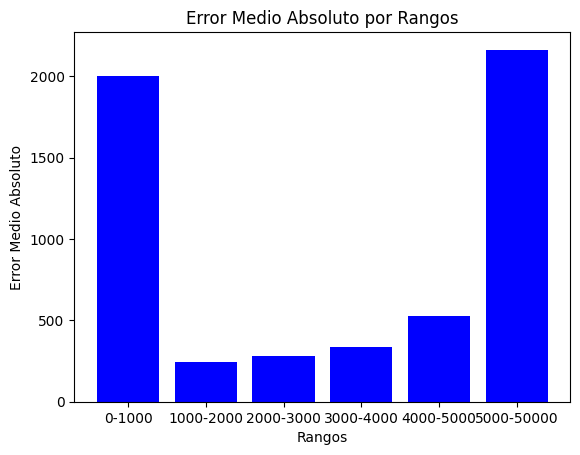

In [ ]:
# Define los rangos
rangos = [(0, 1000), (1000, 2000), (2000, 3000), (3000, 4000), (4000, 5000), (5000, 50000)]
errors = []

# Calcula el error medio absoluto para cada rango
for rango in rangos:
    mask = (y_test > rango[0]) & (y_test <= rango[1])
    y_test_rango = y_test[mask]
    y_pred_rango = y_pred[mask]

    error = mean_absolute_error(y_test_rango, y_pred_rango)
    errors.append(error)

# Crea el gráfico de barras
rango_labels = [f"{rango[0]}-{rango[1]}" for rango in rangos]

plt.bar(rango_labels, errors, color='blue')
plt.xlabel('Rangos')
plt.ylabel('Error Medio Absoluto')
plt.title('Error Medio Absoluto (MSE) por Rangos')
plt.show()

In [ ]:
print("Predicciones para las 5 siguientes propiedades:\n")
print(X_test.head())
print("\n--------------------------------------------------------------------------\n")

Predicciones para las 5 siguientes propiedades:

       metros_cuadrados  dormitorios  banios   latitude  longitude  \
6418                 77            3       2 -33.442952 -70.641222   
3299                 43            2       1 -33.437115 -70.676804   
937                  35            1       1 -33.437155 -70.647947   
10831                40            2       1 -33.447714 -70.653979   
11551                48            2       2 -33.447463 -70.646911   

       centros_comerciales_tiempo(minutos)_min  \
6418                                       6.2   
3299                                     300.0   
937                                        2.0   
10831                                      9.4   
11551                                      7.2   

       centros_comerciales_tiempo(minutos)_max  \
6418                                      11.7   
3299                                     300.0   
937                                        6.7   
10831                        

In [ ]:
print("Las predicciones son:\n")
print(*regr.predict(X_test.head()), sep='\n')
print("\n--------------------------------------------------------------------------\n")
print("El valor real es:\n")
print(y_test.head().to_string(index=False))

Las predicciones son:

3767.6883333333335
1901.1833333333332
2209.737833333333
2804.7175
2846.478521062271

--------------------------------------------------------------------------

El valor real es:

4100
1928
2490
2418
2390


Text(0.5, 1.0, 'Global Feature Importance - Built-in Method')

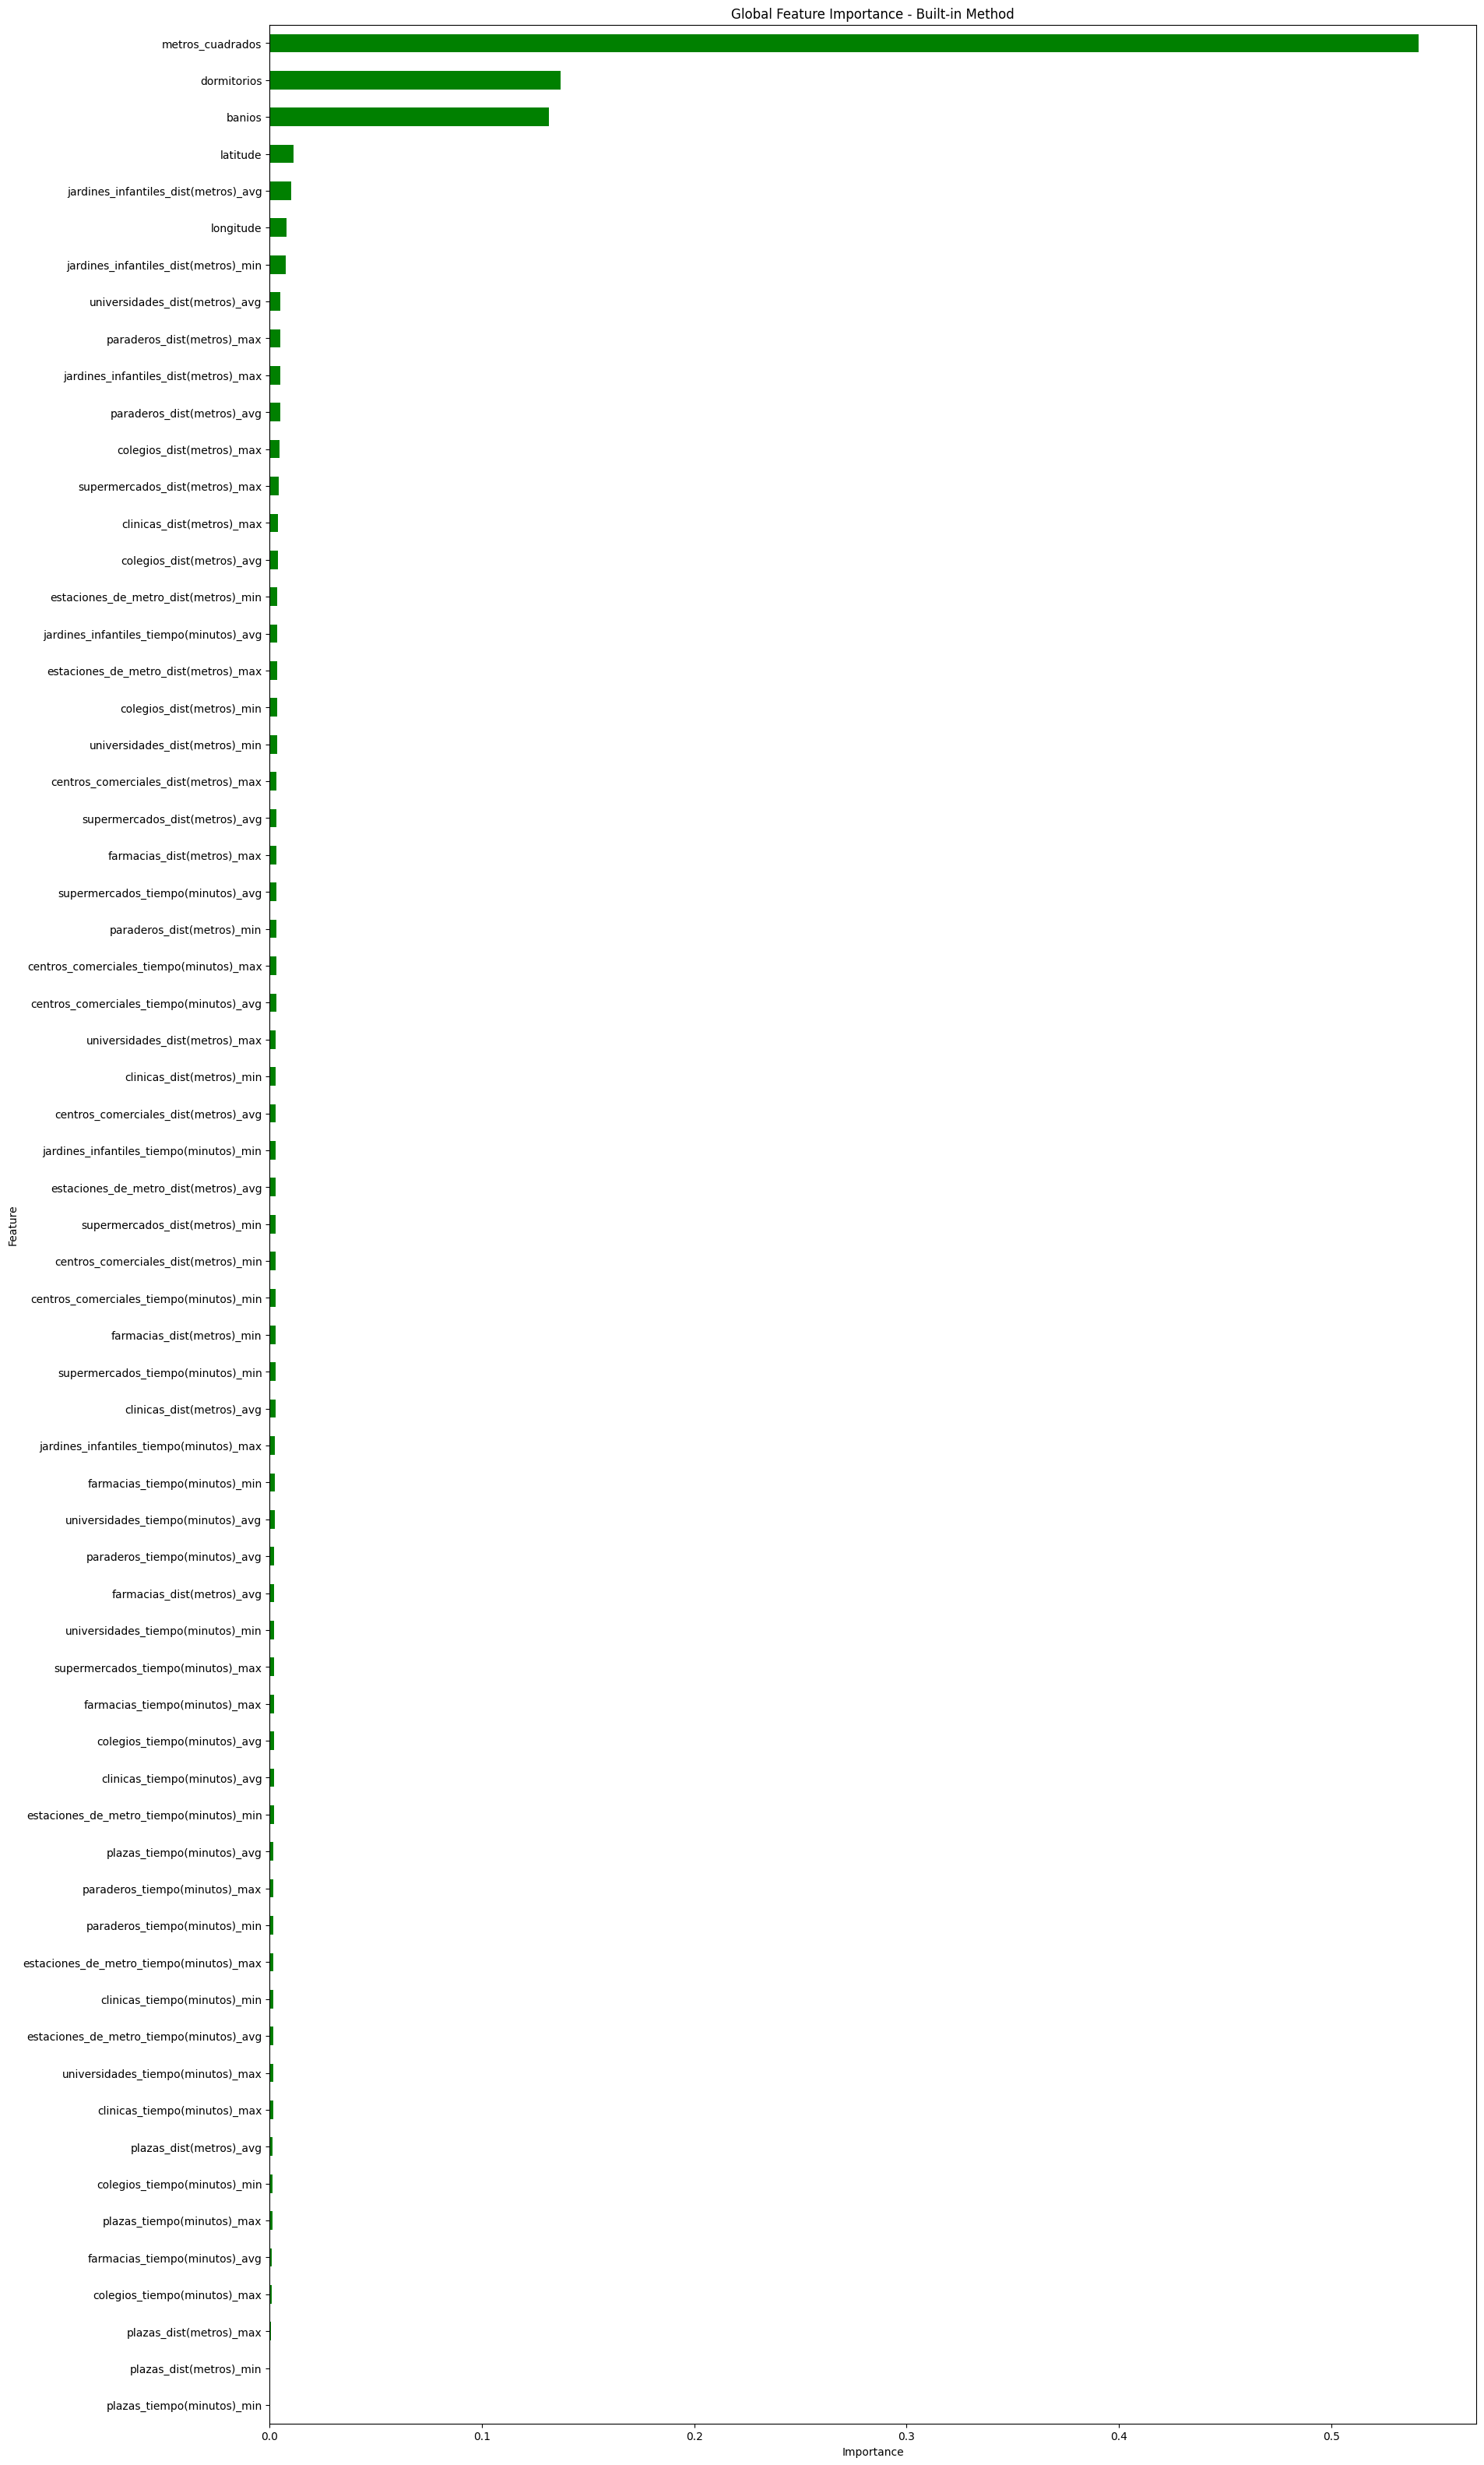

In [ ]:
plt.figure(figsize=(20,40))
global_importances = pd.Series(regr.steps[1][1].feature_importances_, index=X_train.columns)
global_importances.sort_values(ascending=True, inplace=True)
global_importances.plot.barh(color='green')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Global Feature Importance - Built-in Method")

In [ ]:
X_train_selected = X_train[X_train.columns.drop(list(X_train.filter(regex=r'(minutos|_max|_min)')))]
X_test_selected = X_test[X_test.columns.drop(list(X_test.filter(regex=r'(minutos|_max|_min)')))]
X_selected = X[X.columns.drop(list(X.filter(regex=r'(minutos|_max|_min)')))]

In [ ]:
regr = make_pipeline(StandardScaler(), RandomForestRegressor(random_state=42))
regr.fit(X_train_selected, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [ ]:
regr.score(X_train_selected, y_train)

0.9678470699175478

In [ ]:
y_pred = regr.predict(X_test_selected)

In [ ]:
from sklearn.metrics import mean_absolute_error

# Define los rangos
rangos = [(0, 1000), (1000, 2000), (2000, 3000), (3000, 4000), (4000, 5000), (5000, 50000)]

for rango in rangos:
    mask = (y_test > rango[0]) & (y_test <= rango[1])
    y_test_rango = y_test[mask]
    y_pred_rango = y_pred[mask]

    error = mean_absolute_error(y_test_rango, y_pred_rango)
    print(f"Mean absolute error para el rango {rango[0]} - {rango[1]} UF: {error:.2f}")

Mean absolute error para el rango 0 - 1000 UF: 1845.41
Mean absolute error para el rango 1000 - 2000 UF: 241.45
Mean absolute error para el rango 2000 - 3000 UF: 281.04
Mean absolute error para el rango 3000 - 4000 UF: 336.87
Mean absolute error para el rango 4000 - 5000 UF: 529.15
Mean absolute error para el rango 5000 - 50000 UF: 2086.76


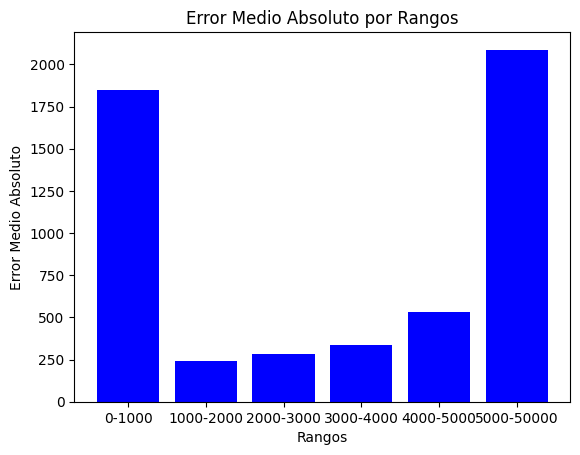

In [ ]:
# Define los rangos
rangos = [(0, 1000), (1000, 2000), (2000, 3000), (3000, 4000), (4000, 5000), (5000, 50000)]
errors = []

# Calcula el error medio absoluto para cada rango
for rango in rangos:
    mask = (y_test > rango[0]) & (y_test <= rango[1])
    y_test_rango = y_test[mask]
    y_pred_rango = y_pred[mask]

    error = mean_absolute_error(y_test_rango, y_pred_rango)
    errors.append(error)

# Crea el gráfico de barras
rango_labels = [f"{rango[0]}-{rango[1]}" for rango in rangos]

plt.bar(rango_labels, errors, color='blue')
plt.xlabel('Rangos')
plt.ylabel('Error Medio Absoluto')
plt.title('Error Medio Absoluto (MSE) por Rangos')
plt.show()

In [ ]:
print("Predicciones para las 5 siguientes propiedades:\n")
print(X_test_selected.head())
print("\n--------------------------------------------------------------------------\n")


Predicciones para las 5 siguientes propiedades:

       metros_cuadrados  dormitorios  banios   latitude  longitude  \
6418                 77            3       2 -33.442952 -70.641222   
3299                 43            2       1 -33.437115 -70.676804   
937                  35            1       1 -33.437155 -70.647947   
10831                40            2       1 -33.447714 -70.653979   
11551                48            2       2 -33.447463 -70.646911   

       centros_comerciales_dist(metros)_avg  clinicas_dist(metros)_avg  \
6418                                  837.5                      590.1   
3299                                 2000.0                      449.0   
937                                   369.7                      577.4   
10831                                 896.0                      737.7   
11551                                 788.7                      574.9   

       colegios_dist(metros)_avg  estaciones_de_metro_dist(metros)_avg  \
6418       

In [ ]:
print("Las predicciones son:\n")
print(*regr.predict(X_test_selected.head()), sep='\n')
print("\n--------------------------------------------------------------------------\n")
print("El valor real es:\n")
print(y_test.head().to_string(index=False))

Las predicciones son:

3809.7
1914.0146666666667
2200.999976190476
2832.6
2757.1344444444444

--------------------------------------------------------------------------

El valor real es:

4100
1928
2490
2418
2390


In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
import multiprocessing
# Grid de hiperparámetros evaluados
# ==============================================================================
param_grid = {
    'randomforestregressor__n_estimators': [100, 200, 300, 400, 500, 600],
    'randomforestregressor__max_depth': [10, 20, 30],
    'randomforestregressor__min_samples_split': [2, 5, 10],
    'randomforestregressor__min_samples_leaf': [1, 2, 4]
}

# Búsqueda por grid search con validación cruzada
# ==============================================================================
grid = GridSearchCV(
        estimator  = regr,
        param_grid = param_grid,
        scoring    = 'neg_mean_absolute_error',
        n_jobs     = multiprocessing.cpu_count() - 3,
        cv         = KFold(n_splits=5, random_state=42, shuffle=True),
        refit      = True,
        verbose    = 0,
        return_train_score = True
       )

grid.fit(X = X_selected, y = y)

# Resultados
# ==============================================================================
resultados = pd.DataFrame(grid.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(3)

In [ ]:
regr = make_pipeline(StandardScaler(), RandomForestRegressor(random_state=42, n_estimators = 500, max_depth=30, min_samples_split=2, min_samples_leaf=1))
regr.fit(X_train_selected, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=30, n_estimators=500,
                                       random_state=42))])

In [ ]:
regr.score(X_train_selected, y_train)

0.969738414176636

In [ ]:
y_pred = regr.predict(X_test_selected)

In [ ]:
from sklearn.metrics import mean_absolute_error

# Define los rangos
rangos = [(0, 1000), (1000, 2000), (2000, 3000), (3000, 4000), (4000, 5000), (5000, 50000)]

for rango in rangos:
    mask = (y_test > rango[0]) & (y_test <= rango[1])
    y_test_rango = y_test[mask]
    y_pred_rango = y_pred[mask]

    error = mean_absolute_error(y_test_rango, y_pred_rango)
    print(f"Mean absolute error para el rango {rango[0]} - {rango[1]} UF: {error:.2f}")

Mean absolute error para el rango 0 - 1000 UF: 1907.73
Mean absolute error para el rango 1000 - 2000 UF: 244.51
Mean absolute error para el rango 2000 - 3000 UF: 279.38
Mean absolute error para el rango 3000 - 4000 UF: 329.74
Mean absolute error para el rango 4000 - 5000 UF: 514.67
Mean absolute error para el rango 5000 - 50000 UF: 2013.76


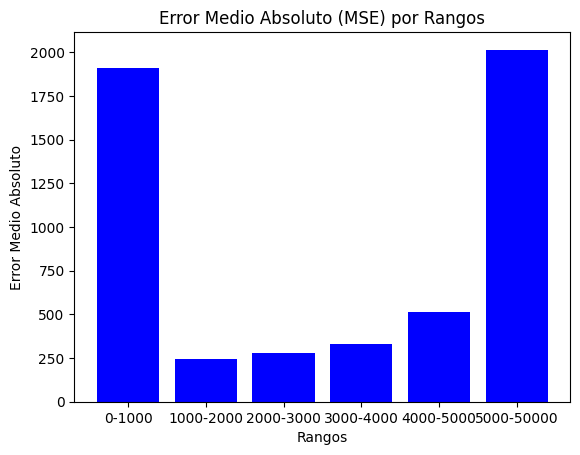

In [ ]:
# Define los rangos
rangos = [(0, 1000), (1000, 2000), (2000, 3000), (3000, 4000), (4000, 5000), (5000, 50000)]
errors = []

# Calcula el error medio absoluto para cada rango
for rango in rangos:
    mask = (y_test > rango[0]) & (y_test <= rango[1])
    y_test_rango = y_test[mask]
    y_pred_rango = y_pred[mask]

    error = mean_absolute_error(y_test_rango, y_pred_rango)
    errors.append(error)

# Crea el gráfico de barras
rango_labels = [f"{rango[0]}-{rango[1]}" for rango in rangos]

plt.bar(rango_labels, errors, color='blue')
plt.xlabel('Rangos')
plt.ylabel('Error Medio Absoluto')
plt.title('Error Medio Absoluto (MSE) por Rangos')
plt.show()

In [ ]:
print("Predicciones para las 5 siguientes propiedades:\n")
print(X_test_selected.head())
print("\n--------------------------------------------------------------------------\n")

Predicciones para las 5 siguientes propiedades:

       metros_cuadrados  dormitorios  banios   latitude  longitude  \
6418                 77            3       2 -33.442952 -70.641222   
3299                 43            2       1 -33.437115 -70.676804   
937                  35            1       1 -33.437155 -70.647947   
10831                40            2       1 -33.447714 -70.653979   
11551                48            2       2 -33.447463 -70.646911   

       centros_comerciales_dist(metros)_avg  clinicas_dist(metros)_avg  \
6418                                  837.5                      590.1   
3299                                 2000.0                      449.0   
937                                   369.7                      577.4   
10831                                 896.0                      737.7   
11551                                 788.7                      574.9   

       colegios_dist(metros)_avg  estaciones_de_metro_dist(metros)_avg  \
6418       

In [ ]:
print("Las predicciones son:\n")
print(*regr.predict(X_test_selected.head()), sep='\n')
print("\n--------------------------------------------------------------------------\n")
print("El valor real es:\n")
print(y_test.head().to_string(index=False))

Las predicciones son:

3804.859
1879.7467333333332
2203.371835754318
2806.1418285714285
2780.3293168807745

--------------------------------------------------------------------------

El valor real es:

4100
1928
2490
2418
2390


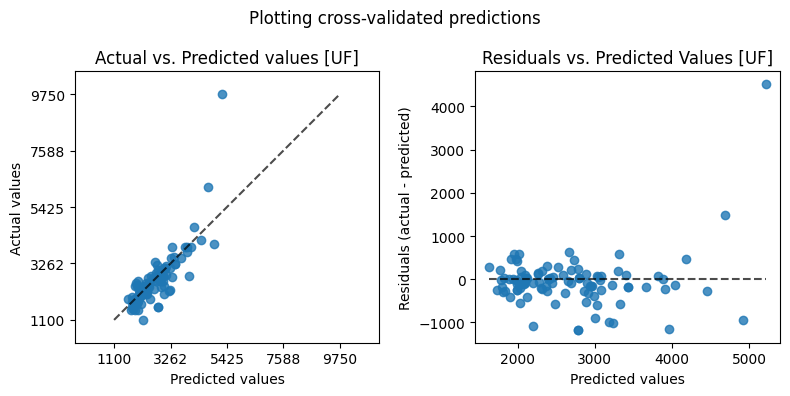

In [ ]:
from sklearn.metrics import PredictionErrorDisplay

fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    subsample=100,
    ax=axs[0],
    random_state=0,
)
axs[0].set_title("Actual vs. Predicted values [UF]")
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred=y_pred,
    kind="residual_vs_predicted",
    subsample=100,
    ax=axs[1],
    random_state=0,
)
axs[1].set_title("Residuals vs. Predicted Values [UF]")
fig.suptitle("Plotting cross-validated predictions")
plt.tight_layout()
plt.show()

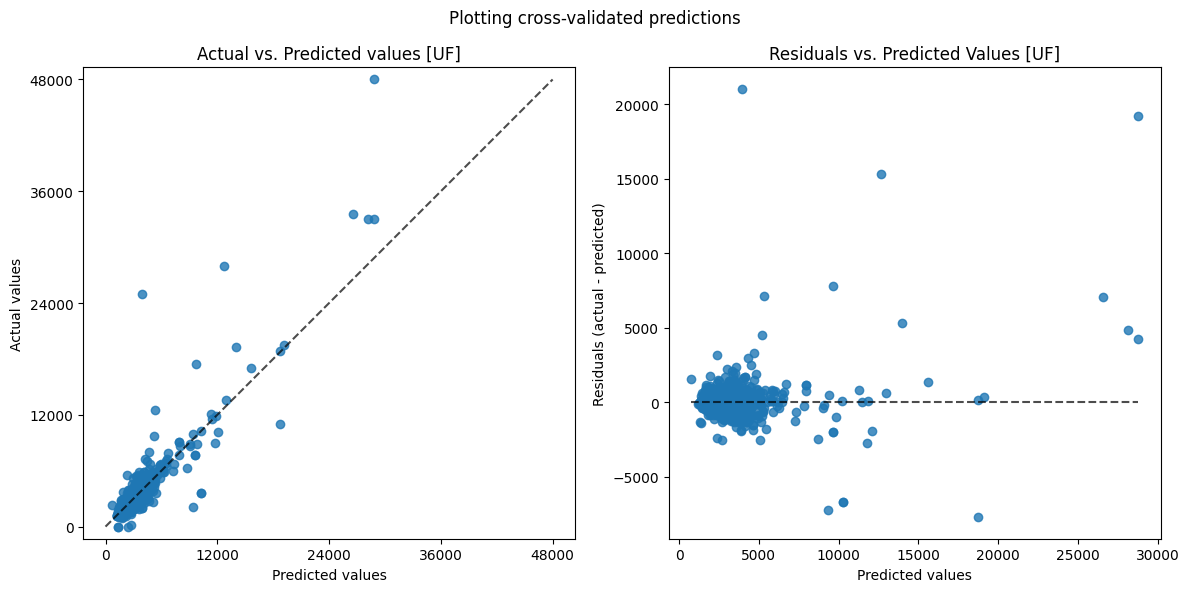

In [ ]:
from sklearn.metrics import PredictionErrorDisplay

fig, axs = plt.subplots(ncols=2, figsize=(12, 6))
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    subsample=10000,
    ax=axs[0],
    random_state=0,
)
axs[0].set_title("Actual vs. Predicted values [UF]")
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred=y_pred,
    kind="residual_vs_predicted",
    subsample=10000,
    ax=axs[1],
    random_state=0,
)
axs[1].set_title("Residuals vs. Predicted Values [UF]")
fig.suptitle("Plotting cross-validated predictions")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Global Feature Importance - Built-in Method')

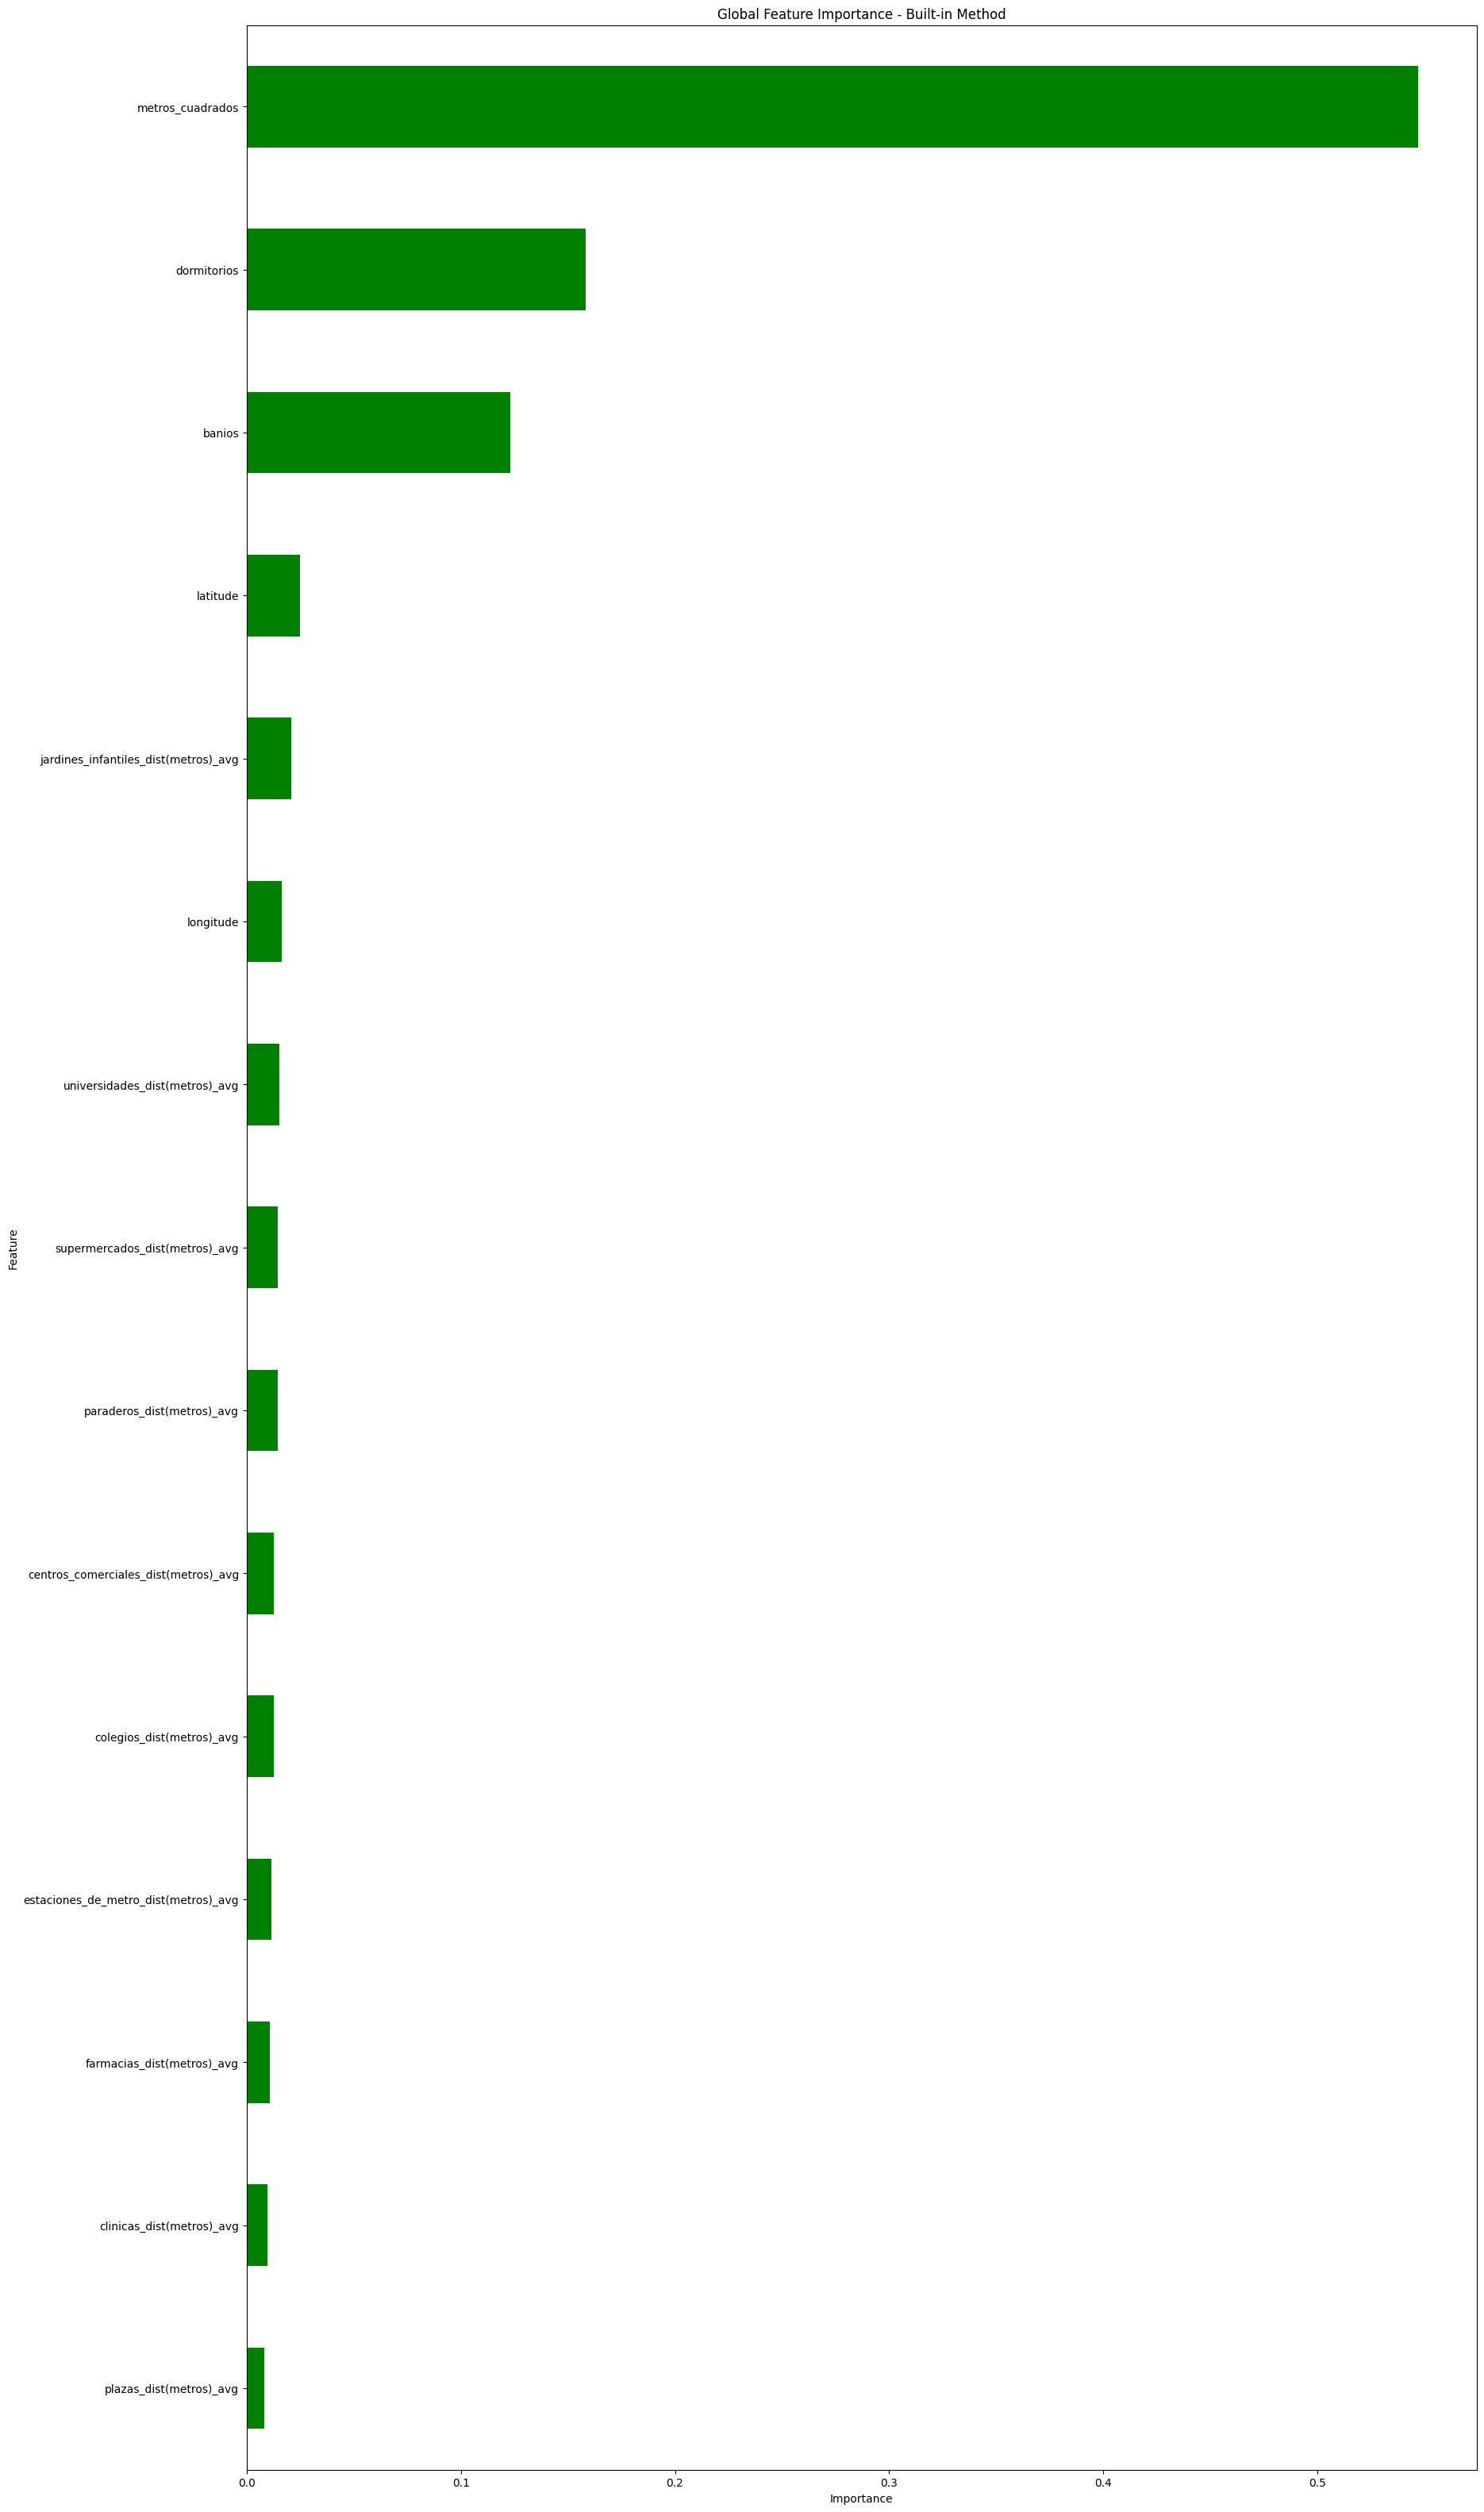

In [ ]:
plt.figure(figsize=(20,40))
global_importances = pd.Series(regr.steps[1][1].feature_importances_, index=X_train_selected.columns)
global_importances.sort_values(ascending=True, inplace=True)
global_importances.plot.barh(color='green')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Global Feature Importance - Built-in Method")

In [ ]:
import joblib

joblib.dump(regr, "./modelo_data_science.joblib")

X_test_selected.to_csv('formato.csv', index=False)

y_test.to_csv('valores.csv', index=False)

# MODELO RANDOMFOREST CON PCA


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

regr_pca = make_pipeline(StandardScaler(), PCA(), RandomForestRegressor(random_state=42, n_estimators = 300, max_depth=30, min_samples_split=2, min_samples_leaf=1))
regr_pca.fit(X_train_selected, y_train)

NameError: name 'X_train_selected' is not defined

In [ ]:
regr_pca.score(X_train_selected, y_train)

0.9557245502199144

In [ ]:
regr_pca.set_params

<bound method Pipeline.set_params of Pipeline(steps=[('standardscaler', StandardScaler()), ('pca', PCA()),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=30, n_estimators=300,
                                       random_state=42))])>

In [ ]:
y_pred_pca = regr_pca.predict(X=X_test_selected)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred_pca))

Mean absolute error: 418.33


In [ ]:
print("Predicciones para las 5 siguientes propiedades:\n")
print(X_test_selected.head())
print("\n--------------------------------------------------------------------------\n")

Predicciones para las 5 siguientes propiedades:

       metros_cuadrados  dormitorios  banios   latitude  longitude  \
6418                 77            3       2 -33.442952 -70.641222   
3299                 43            2       1 -33.437115 -70.676804   
937                  35            1       1 -33.437155 -70.647947   
10831                40            2       1 -33.447714 -70.653979   
11551                48            2       2 -33.447463 -70.646911   

       centros_comerciales_dist(metros)_avg  clinicas_dist(metros)_avg  \
6418                                  837.5                      590.1   
3299                                 2000.0                      449.0   
937                                   369.7                      577.4   
10831                                 896.0                      737.7   
11551                                 788.7                      574.9   

       colegios_dist(metros)_min  colegios_dist(metros)_avg  \
6418                  

In [ ]:
print("Las predicciones son:\n")
print(*regr_pca.predict(X_test_selected.head()), sep='\n')
print("\n--------------------------------------------------------------------------\n")
print("El valor real es:\n")
print(y_test.head().to_string(index=False))

Las predicciones son:

4319.481111111111
1933.47397477446
2154.9135237837377
2817.8218863988495
3064.1377697538596

--------------------------------------------------------------------------

El valor real es:

4100
1928
2490
2418
2390


In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
import multiprocessing
# Grid de hiperparámetros evaluados
# ==============================================================================
param_grid = {'pca__n_components': [1, 2, 4, 6, 8, 10, 12, 13, 15, 17, 18, 20]}

# Búsqueda por grid search con validación cruzada
# ==============================================================================
grid = GridSearchCV(
        estimator  = regr_pca,
        param_grid = param_grid,
        scoring    = 'neg_mean_absolute_error',
        n_jobs     = multiprocessing.cpu_count() - 3,
        cv         = KFold(n_splits=5, random_state=42, shuffle=True),
        refit      = True,
        verbose    = 0,
        return_train_score = True
       )

grid.fit(X = X_train_selected, y = y_train)

# Resultados
# ==============================================================================
resultados = pd.DataFrame(grid.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(3)

,param_pca__n_components,mean_test_score,std_test_score,mean_train_score,std_train_score
4,8,-430.006698,25.380647,-171.312589,2.585660
5,10,-431.246487,27.863714,-172.372987,2.613381
7,13,-434.366816,28.749815,-174.225570,3.427195


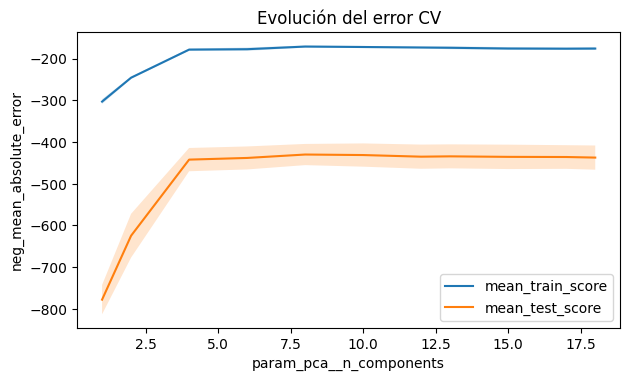

In [ ]:
# Gráfico resultados validación cruzada para cada hiperparámetro
# ==============================================================================
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 3.84), sharey=True)

resultados.plot('param_pca__n_components', 'mean_train_score', ax=ax)
resultados.plot('param_pca__n_components', 'mean_test_score', ax=ax)
ax.fill_between(resultados.param_pca__n_components.astype(float),
                resultados['mean_train_score'] + resultados['std_train_score'],
                resultados['mean_train_score'] - resultados['std_train_score'],
                alpha=0.2)
ax.fill_between(resultados.param_pca__n_components.astype(float),
                resultados['mean_test_score'] + resultados['std_test_score'],
                resultados['mean_test_score'] - resultados['std_test_score'],
                alpha=0.2)
ax.legend()
ax.set_title('Evolución del error CV')
ax.set_ylabel('neg_mean_absolute_error');

In [ ]:
# Mejores hiperparámetros por validación cruzada
# ==============================================================================
print("----------------------------------------")
print("Mejores hiperparámetros encontrados (cv)")
print("----------------------------------------")
print(grid.best_params_, ":", grid.best_score_, grid.scoring)

----------------------------------------
Mejores hiperparámetros encontrados (cv)
----------------------------------------
{'pca__n_components': 8} : -430.00669802661395 neg_mean_absolute_error


In [ ]:
# Entrenamiento modelo de regresión precedido por PCA con escalado
# ==============================================================================
regr_pca = make_pipeline(StandardScaler(), PCA(n_components=8), RandomForestRegressor(random_state=42, n_estimators = 300, max_depth=30, min_samples_split=2, min_samples_leaf=1))
regr_pca.fit(X=X_train_selected, y=y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('pca', PCA(n_components=8)),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=30, n_estimators=300,
                                       random_state=42))])

In [ ]:
regr_pca.score(X_train_selected, y_train)

0.9578969765245304

In [ ]:
y_pred_pca = regr_pca.predict(X=X_test_selected)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred_pca))

Mean absolute error: 405.77


In [ ]:
print("Predicciones para las 5 siguientes propiedades:\n")
print(X_test_selected.head())
print("\n--------------------------------------------------------------------------\n")

Predicciones para las 5 siguientes propiedades:

       metros_cuadrados  dormitorios  banios   latitude  longitude  \
6418                 77            3       2 -33.442952 -70.641222   
3299                 43            2       1 -33.437115 -70.676804   
937                  35            1       1 -33.437155 -70.647947   
10831                40            2       1 -33.447714 -70.653979   
11551                48            2       2 -33.447463 -70.646911   

       centros_comerciales_dist(metros)_avg  clinicas_dist(metros)_avg  \
6418                                  837.5                      590.1   
3299                                 2000.0                      449.0   
937                                   369.7                      577.4   
10831                                 896.0                      737.7   
11551                                 788.7                      574.9   

       colegios_dist(metros)_min  colegios_dist(metros)_avg  \
6418                  

In [ ]:
print("Las predicciones son:\n")
print(*regr_pca.predict(X_test_selected.head()), sep='\n')
print("\n--------------------------------------------------------------------------\n")
print("El valor real es:\n")
print(y_test.head().to_string(index=False))

Las predicciones son:

4653.694444444445
1935.6444444444446
2099.977117907571
2825.1329677219096
2955.5162594268477

--------------------------------------------------------------------------

El valor real es:

4100
1928
2490
2418
2390


# MODELO SVR

In [ ]:
from sklearn.svm import LinearSVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

regr = make_pipeline(StandardScaler(), LinearSVR(random_state=42, tol=1e-5))
regr.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvr', LinearSVR(random_state=42, tol=1e-05))])

In [ ]:
regr.score(X_train, y_train)

0.38243326320069126

In [ ]:
y_pred = regr.predict(X=X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))

Mean absolute error: 618.06


In [ ]:
print("Predicciones para las 5 siguientes propiedades:\n")
print(X_test.head())
print("\n--------------------------------------------------------------------------\n")

Predicciones para las 5 siguientes propiedades:

       metros_cuadrados  dormitorios  banios   latitude  longitude  \
6418                 77            3       2 -33.442952 -70.641222   
3299                 43            2       1 -33.437115 -70.676804   
937                  35            1       1 -33.437155 -70.647947   
10831                40            2       1 -33.447714 -70.653979   
11551                48            2       2 -33.447463 -70.646911   

       centros_comerciales_tiempo(minutos)_min  \
6418                                       6.2   
3299                                     300.0   
937                                        2.0   
10831                                      9.4   
11551                                      7.2   

       centros_comerciales_tiempo(minutos)_max  \
6418                                      11.7   
3299                                     300.0   
937                                        6.7   
10831                        

In [ ]:
print("Las predicciones son:\n")
print(*regr.predict(X_test.head()), sep='\n')
print("\n--------------------------------------------------------------------------\n")
print("El valor real es:\n")
print(y_test.head().to_string(index=False))

Las predicciones son:

3438.928827453488
2323.5486398314283
2106.1494121269557
2426.4500794760133
2843.0620706722857

--------------------------------------------------------------------------

El valor real es:

4100
1928
2490
2418
2390


In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
import multiprocessing
# Grid de hiperparámetros evaluados
# ==============================================================================
param_grid = {'linearsvr__C': [0.1, 1, 10, 100],
              'linearsvr__epsilon': [0, 0.1, 0.2, 0.5, 0.9, 1, 1.1, 2],
              'linearsvr__tol': [1e-3, 1e-4, 1e-5]}

# Búsqueda por grid search con validación cruzada
# ==============================================================================
grid = GridSearchCV(
        estimator  = regr,
        param_grid = param_grid,
        scoring    = 'neg_mean_absolute_error',
        n_jobs     = multiprocessing.cpu_count() - 1,
        cv         = KFold(n_splits=5, random_state=42, shuffle=True),
        refit      = True,
        verbose    = 0,
        return_train_score = True
       )

grid.fit(X = X_train, y = y_train)

# Resultados
# ==============================================================================
resultados = pd.DataFrame(grid.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(3)

,param_linearsvr__C,param_linearsvr__epsilon,param_linearsvr__tol,mean_test_score,std_test_score,mean_train_score,std_train_score
65,10.0,1.0,0.00001,-594.590054,40.695659,-590.398054,9.804729
50,10.0,0.0,0.00001,-594.610381,40.686269,-590.402094,9.814414
62,10.0,0.9,0.00001,-594.616375,40.711171,-590.396616,9.803391


In [ ]:
from sklearn.svm import LinearSVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

regr = make_pipeline(StandardScaler(), LinearSVR(random_state=42, tol=1e-4, C=10, epsilon=1))
regr.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvr', LinearSVR(C=10, epsilon=1, random_state=42))])

In [ ]:
regr.score(X_train, y_train)

0.44585850070108335

In [ ]:
y_pred = regr.predict(X=X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))

Mean absolute error: 593.77


In [ ]:
print("Predicciones para las 5 siguientes propiedades:\n")
print(X_test.head())
print("\n--------------------------------------------------------------------------\n")

Predicciones para las 5 siguientes propiedades:

       metros_cuadrados  dormitorios  banios   latitude  longitude  \
6418                 77            3       2 -33.442952 -70.641222   
3299                 43            2       1 -33.437115 -70.676804   
937                  35            1       1 -33.437155 -70.647947   
10831                40            2       1 -33.447714 -70.653979   
11551                48            2       2 -33.447463 -70.646911   

       centros_comerciales_tiempo(minutos)_min  \
6418                                       6.2   
3299                                     300.0   
937                                        2.0   
10831                                      9.4   
11551                                      7.2   

       centros_comerciales_tiempo(minutos)_max  \
6418                                      11.7   
3299                                     300.0   
937                                        6.7   
10831                        

In [ ]:
print("Las predicciones son:\n")
print(*regr.predict(X_test.head()), sep='\n')
print("\n--------------------------------------------------------------------------\n")
print("El valor real es:\n")
print(y_test.head().to_string(index=False))

Las predicciones son:

3877.1511803041717
2468.3488118753385
2201.604352143603
2538.56415513272
3059.6793251933454

--------------------------------------------------------------------------

El valor real es:

4100
1928
2490
2418
2390
